In [1]:
# Carico il dataset con pandas
import pandas as pd

df = pd.read_csv("data.csv", sep=",")
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,class
0,-0.215992,0.937936,0.241359,-0.668918,1.693917,1.457161,0.689197,0.873766,-1.821509,0.324794,-1.173070,-1.563108,0.457026,1.087886,-0.812614,0
1,-0.741775,-0.684866,1.252277,1.361965,2.704220,0.226251,-1.267856,-0.407535,-2.556289,-0.305512,0.651823,2.524385,2.055355,1.484632,-0.053968,1
2,0.747766,1.231494,0.603151,-2.456016,2.273604,-1.295895,2.207668,0.220437,-2.680646,-1.860033,-0.091534,-2.157404,1.003022,1.360310,-1.694517,0
3,-0.409211,-0.111560,-0.126949,2.615009,-3.178556,0.303432,2.134776,-0.050978,1.024098,0.305872,0.393733,-3.514744,1.619199,0.080896,-0.439400,0
4,-0.344474,1.324711,-0.659647,0.620086,1.610876,-0.510676,2.943440,-1.036055,-1.653075,0.810382,-0.367530,1.467321,0.535110,2.871521,0.039601,0


In [2]:
from sklearn.model_selection import train_test_split

# Check dei valori nulli se ci sono
valori_mancanti = (df.isnull().sum()/len(df))*100
#print(valori_mancanti)

# Train test split
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05, random_state = 42, stratify=y) 

In [3]:
import numpy as np

# Matrice di correlazione tra le feature
mat_corr = X_train.corr().abs()
np.fill_diagonal(mat_corr.values, 0)

# Soglia 
threshold = 0.6
coppie_individuate = mat_corr.unstack().sort_values(ascending = False).drop_duplicates()
coppie_individuate = coppie_individuate[coppie_individuate> threshold]

print(f"Coppie con corr > {threshold}:")
print(coppie_individuate.head(20))

Coppie con corr > 0.6:
feature_4  feature_13    0.834696
           feature_8     0.820896
           feature_7     0.681278
feature_7  feature_13    0.680366
dtype: float64


In [4]:
# Combinazione lineare
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

colonne_da_buttare = []

for c1, c2 in coppie_individuate.index:
    feature = f"PCA_{c1}_{c2}"
    # Scaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[[c1,c2]])
    X_test_scaled = scaler.transform(X_test[[c1,c2]])
    #Inizializzo la PCA
    pca = PCA(n_components=1)
    # Applichiamo la PCA + lo slicing per evitare conflitti dimensionali
    X_train[feature] = pca.fit_transform(X_train_scaled)[:, 0]
    X_test[feature] = pca.transform(X_test_scaled)[:, 0]
    colonne_da_buttare.extend([c1, c2])# Extend va a riempire il vettore
colonne_da_buttare = list(set(colonne_da_buttare))#con set ovvero "insieme" per def non contiene duplicati--> evita di andare in crash

# Elimino definitivamente le colonne originali
X_train = X_train.drop(columns=colonne_da_buttare)
X_test = X_test.drop(columns=colonne_da_buttare)
print(f"Colonne eliminate: {colonne_da_buttare}")

Colonne eliminate: ['feature_8', 'feature_7', 'feature_4', 'feature_13']


In [5]:
# Seleziono le feature rilevanti tramite il Fisher Score
from sklearn.feature_selection import SelectKBest, f_classif

selettore = SelectKBest(f_classif, k=10).fit(X_train, y_train)
colonne_top = X_train.columns[selettore.get_support()]
X_train = X_train[colonne_top].astype(np.float32)
X_test = X_test[colonne_top].astype(np.float32)

print("Feature mantenute per i prossimi punti:", list(colonne_top))


Feature mantenute per i prossimi punti: ['feature_1', 'feature_2', 'feature_3', 'feature_6', 'feature_9', 'feature_11', 'PCA_feature_4_feature_13', 'PCA_feature_4_feature_8', 'PCA_feature_4_feature_7', 'PCA_feature_7_feature_13']


In [6]:
# 2
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
n_samples = X_train_scaled.shape[0]
c_y = 1/np.sqrt(n_samples)

# Iper parametri
iper_parametri = [
    {'C': [1, c_y], 'kernel': ['rbf']},
    {'C': [1, c_y], 'kernel': ['poly'], 'degree': [3, 4]}
]
svm = SVC(probability=True, random_state= 42)
ricerca = GridSearchCV(estimator=svm,
                       param_grid=iper_parametri,
                       scoring='accuracy',
                       n_jobs = -1)
print("Ricerca iperparametri migliori...")
ricerca.fit(X_train_scaled, y_train)
best_model = ricerca.best_estimator_
y_predict = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_predict)

print(f"\nMIGLIORI IPERPARAMETRI: {ricerca.best_params_} \nACCURACY DEL MIGLIOR CLASSIFICATORE:{ricerca.best_score_}")
print(f"TEST ACCURACY: {accuracy}")

Ricerca iperparametri migliori...

MIGLIORI IPERPARAMETRI: {'C': 1, 'kernel': 'rbf'} 
ACCURACY DEL MIGLIOR CLASSIFICATORE:0.9414035087719299
TEST ACCURACY: 0.94


In [7]:
#3 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchnn

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.10, random_state= 42, stratify= y_train)

X_tr_t = torch.tensor(X_tr.values, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr.values, dtype=torch.long)

X_val_t = torch.tensor(X_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

class DenseNN(nn.Module):
    def __init__(self, input_dim):
        super(DenseNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32,2)
        )
    def forward(self, x):
        return self.net(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNN(X_tr.shape[1]).to(device)

In [8]:
from tqdm import trange

criterio = nn.CrossEntropyLoss()
ottimizzatore = optim.RMSprop(
    model.parameters(),
    lr = 0.001,
    weight_decay=0.1,
    momentum=0.1,
    centered=True
)

early_stopping = torchnn.EarlyStopping(patience=5, min_delta=0.01)

best_validation_accuracy = 0.0
print("Addestramento della NN AKA NIGGER-NETWORK")
for epoch in range(1, 101):
    pbar = trange(len(train_loader))
    pbar.set_description(desc = f'Epoch {epoch:4d}')
    #TRAIN
    train_loss = torchnn.train_loop(model, train_loader, ottimizzatore, device, pbar, criterio)
    #VALIDATION
    val_loss, val_acc, _ = torchnn.eval_loop(model, val_loader, device, criterio)
    print(f" -> Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")
    # CHECKPOINT
    if val_acc > best_validation_accuracy:
        best_validation_accuracy = val_acc
        torch.save(model.state_dict(), 'miglior_modello.pth')
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"Early Stopping all'epoca: {epoch}")
        break
        

Addestramento della NN AKA NIGGER-NETWORK


Epoch    1: 100%|██████████| 81/81 [00:00<00:00, 105.46it/s]


 -> Val Loss: 0.3440 | Val Accuracy: 0.8877


Epoch    2: 100%|██████████| 81/81 [00:00<00:00, 239.63it/s]


 -> Val Loss: 0.3459 | Val Accuracy: 0.8772


...

 -> Val Loss: 0.3299 | Val Accuracy: 0.8877


Epoch    8: 100%|██████████| 81/81 [00:00<00:00, 257.96it/s]


 -> Val Loss: 0.3534 | Val Accuracy: 0.8912


Epoch    9: 100%|██████████| 81/81 [00:00<00:00, 251.58it/s]

 -> Val Loss: 0.3278 | Val Accuracy: 0.9018
Early Stopping all'epoca: 9


[SVM Non Lineare] Accuracy: 0.9400 | AUC: 0.9691


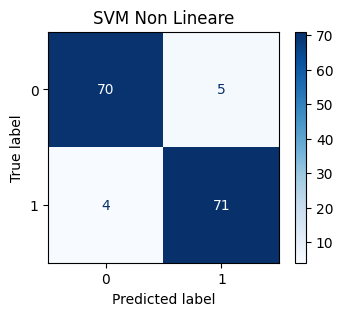

[Rete Neurale] Accuracy: 0.8733 | AUC: 0.9408


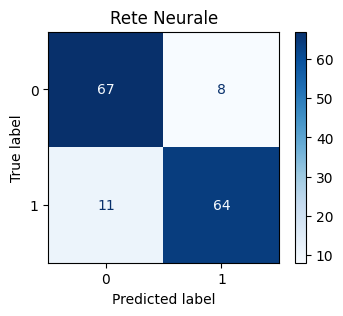

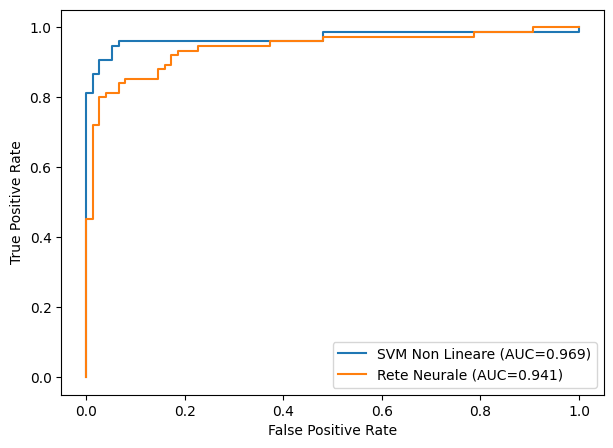

In [12]:
# 4 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay

# Uniformiamo y_test in formato array
y_test_np = y_test.values
X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)

# SVM
y_pred_svm = best_model.predict(X_test_scaled)
y_prob_svm = best_model.predict_proba(X_test_scaled)[:, 1] 

# Rete Neurale
model.load_state_dict(torch.load('miglior_modello.pth', weights_only=True))
model.eval()
with torch.no_grad():
    out = model(X_test_t)
    y_pred_nn = out.argmax(1).cpu().numpy()
    y_prob_nn = torch.softmax(out, dim=1)[:, 1].cpu().numpy()

# Plot e Metriche
modelli = [("SVM Non Lineare", y_pred_svm, y_prob_svm), ("Rete Neurale", y_pred_nn, y_prob_nn)]
dati_roc = []

for nome, y_pred, y_prob in modelli:
    auc = roc_auc_score(y_test_np, y_prob)
    cm = confusion_matrix(y_test_np, y_pred)
    
    print(f"[{nome}] Accuracy: {accuracy_score(y_test_np, y_pred):.4f} | AUC: {auc:.4f}")
    
    # Matrice di Confusione Visiva
    plt.figure(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title(f'{nome}')
    plt.show()
    
    # Salva dati per la ROC
    fpr, tpr, _ = roc_curve(y_test_np, y_prob)
    dati_roc.append((nome, fpr, tpr, auc))

# Roc
plt.figure(figsize=(7, 5))
for nome, fpr, tpr, auc in dati_roc:
    plt.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()